# Solving the transient Richards equation
The goal is to solve the transient mixed Richards equation. <br>

$\frac{\partial \theta}{\partial t} - \nabla\cdot(k\nabla(z+h)) = 0$ <br>

which means that the hydraulic pressure head is negative above the saturation zone. <br>
Here the parametrizations are simplified to: <br>
$k=k_sk_r$ with $k_r = e^{\alpha h}$ (Gardner),<br> 
$k_r = (\frac{\theta - \theta_r}{\theta_s - \theta_r})^m$ (Irmay) <br>
where $\alpha, m$ are parameters. For even further simplification we choose $m=1$ here. (I.e. $\theta = \theta_r + (\theta_s-\theta_r)e^{\alpha h}$)<br>
We choose $\Omega = [0, a=15.24]\times[0, L=15.24]$, $\alpha=0.19$ and $h_r = -15.24$. <br>

Boundary conditions: <br>
- $h=h_r$ on $x=0,~x=a,~z=0$
- $h = \frac{1}{\alpha}\ln(e^{\alpha h_r}+\bar h_0\sin(\frac{\pi x}{a}))$ with $\bar h_0 = 1-e^{\alpha h_r}$ on $z=L$

Initial condition: $h=h_r$ at $t=0$ everywhere.

In [1]:
import numpy as np
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    functionspace,
    dirichletbc,
    locate_dofs_geometrical,
    form,
    extract_function_spaces,
)
from dolfinx.fem.petsc import (
    LinearProblem, 
    NonlinearProblem, 
    create_matrix, 
    create_vector, 
    assemble_matrix, 
    assemble_vector,
    apply_lifting,
    set_bc,
    )
from dolfinx.mesh import create_unit_square, locate_entities, meshtags, create_rectangle, CellType
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
from ufl import (
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    dx,
    grad,
    div,
    inner,
    exp,
    lhs,
    rhs,
    derivative,
    conditional,
    sqrt,
    ln,
)

from petsc4py import PETSc

In [23]:
# Define time discretization parameters
t = 0.0 # start time
T = 800 # end time
num_steps = 30
delta_t = T/num_steps

# Define constants
alpha = 0.19 # Gardner exponent
theta_r = 0.15 # residual water content
theta_s = 0.45 # saturated water content
L = a = 15.24 # height, length of box
h_r = -15.24 # pressure head when the soil is very dry
Ks = 3e-5 # saturated hydraulic conductivity

# Solution constants
h_0 = 1 - np.exp(alpha*h_r)
beta = np.sqrt(alpha**2/4 + (np.pi/a)**2)
beta_1 = np.sqrt(alpha**2/4 + (np.pi*2/a)**2)
h_0

np.float64(0.9447341443685314)

In [24]:
# Create mesh
domain = create_rectangle(MPI.COMM_WORLD, ((0,0), (a, L)), (100,100), cell_type=CellType.quadrilateral)
V = functionspace(domain, ("CG", 1)) # linear Lagrange
x = SpatialCoordinate(domain)


def kr(u):
    return exp(alpha*u)

def C(u):
    # C(h)=dtheta/dh
    return alpha*(theta_s - theta_r)*kr(u)

def theta(u):
    return theta_r + (theta_s - theta_r)*kr(u)

In [25]:
# Define Dirichlet boundary conditions

def left_or_right(x):
    return np.logical_or(np.isclose(x[0], 0), np.isclose(x[0], a))

dofs_fix = locate_dofs_geometrical(
    V, lambda x: np.logical_or(left_or_right(x), np.isclose(x[1], 0)))
bc_fix = dirichletbc(Constant(domain, default_scalar_type(h_r)), dofs_fix, V)

dofs_no = locate_dofs_geometrical(V, lambda x: np.isclose(x[1], 0))
bc_no = dirichletbc(Constant(domain, default_scalar_type(h_r)), dofs_no, V)

def expr_h_fix(x):
    return 1/alpha*np.log(np.exp(alpha*h_r) + h_0*np.sin(np.pi*x[0]/a))

def expr_h_noflow(x):
    return 1/alpha*np.log(np.exp(alpha*h_r) + h_0/2*(1-np.cos(2*np.pi*x[0]/a)))


dofs_L = locate_dofs_geometrical(V, lambda x: np.isclose(x[1], L))

h_top_fix = Function(V)
h_top_fix.interpolate(expr_h_fix)
bc_top_fix = dirichletbc(h_top_fix, dofs_L)

h_top_no = Function(V)
h_top_no.interpolate(expr_h_noflow)
bc_top_no = dirichletbc(h_top_no, dofs_L)

In [26]:
v = TestFunction(V)

u_n = Function(V)
u_n.x.array[:] = h_r # previous (time step) solution

max_iter = 10 # maximum number of Picard iterations
tol = 1e-6

for n in range(num_steps):
    u_m = Function(V)
    u_m.x.array[:] = u_n.x.array # First guess for Picard: previous time step
    du = TrialFunction(V)
    
    # Build variational formulation
    C_part = 1/delta_t * C(u_m) * du * v * dx
    var_part = inner(Ks * kr(u_m) * grad(du), grad(v)) * dx
    rest = inner(Ks * kr(u_m) * grad(u_m + x[1]), grad(v)) * dx + (theta(u_m) - theta(u_n)) / delta_t  * v * dx
    F = C_part + var_part + rest
    a_fem = lhs(F)
    L_fem = rhs(F)

    #du = Function(V)
    u_mp1 = Function(V)

    # Prepare Picard iteration
    m = 0 # iteration count
    eps = 1

    while eps > tol and m < max_iter:
        # Calculate boundary conditions for du: du@bd = u_D - u_m@bd
        du_top_fix = Function(V)
        du_top_fix.interpolate(expr_h_fix)
        du_top_fix.x.array[:] = du_top_fix.x.array - u_m.x.array
        bc_du_top = dirichletbc(du_top_fix, dofs_L)

        du_rest = Function(V)
        du_rest.x.array[:] = h_r - u_m.x.array
        bc_du = dirichletbc(du_rest, dofs_fix)

        problem = LinearProblem(
            a_fem, L_fem, bcs=[bc_du, bc_du_top],
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix="Picard_"
            )
        du = problem.solve()
        u_mp1.x.array[:] = u_m.x.array + du.x.array
        eps = np.linalg.norm(du.x.array, ord=np.inf)
        print(f"Time step {n}, iteration {m}, Error ||u_n^m-u_n^(m+1)|| {eps:.3e}")
        u_m.x.array[:] = u_mp1.x.array
        m += 1

    u_n.x.array[:] = u_mp1.x.array

Time step 0, iteration 0, Error ||u_n^m-u_n^(m+1)|| 1.524e+01
Time step 0, iteration 1, Error ||u_n^m-u_n^(m+1)|| 5.201e+00
Time step 0, iteration 2, Error ||u_n^m-u_n^(m+1)|| 1.374e+00
Time step 0, iteration 3, Error ||u_n^m-u_n^(m+1)|| 2.289e-01
Time step 0, iteration 4, Error ||u_n^m-u_n^(m+1)|| 3.541e-02
Time step 0, iteration 5, Error ||u_n^m-u_n^(m+1)|| 8.109e-03
Time step 0, iteration 6, Error ||u_n^m-u_n^(m+1)|| 2.132e-03
Time step 0, iteration 7, Error ||u_n^m-u_n^(m+1)|| 4.726e-04
Time step 0, iteration 8, Error ||u_n^m-u_n^(m+1)|| 5.743e-05
Time step 0, iteration 9, Error ||u_n^m-u_n^(m+1)|| 1.627e-05
Time step 1, iteration 0, Error ||u_n^m-u_n^(m+1)|| 2.777e+00
Time step 1, iteration 1, Error ||u_n^m-u_n^(m+1)|| 5.015e-01
Time step 1, iteration 2, Error ||u_n^m-u_n^(m+1)|| 7.682e-02
Time step 1, iteration 3, Error ||u_n^m-u_n^(m+1)|| 2.129e-02
Time step 1, iteration 4, Error ||u_n^m-u_n^(m+1)|| 5.753e-03
Time step 1, iteration 5, Error ||u_n^m-u_n^(m+1)|| 8.633e-04
Time ste

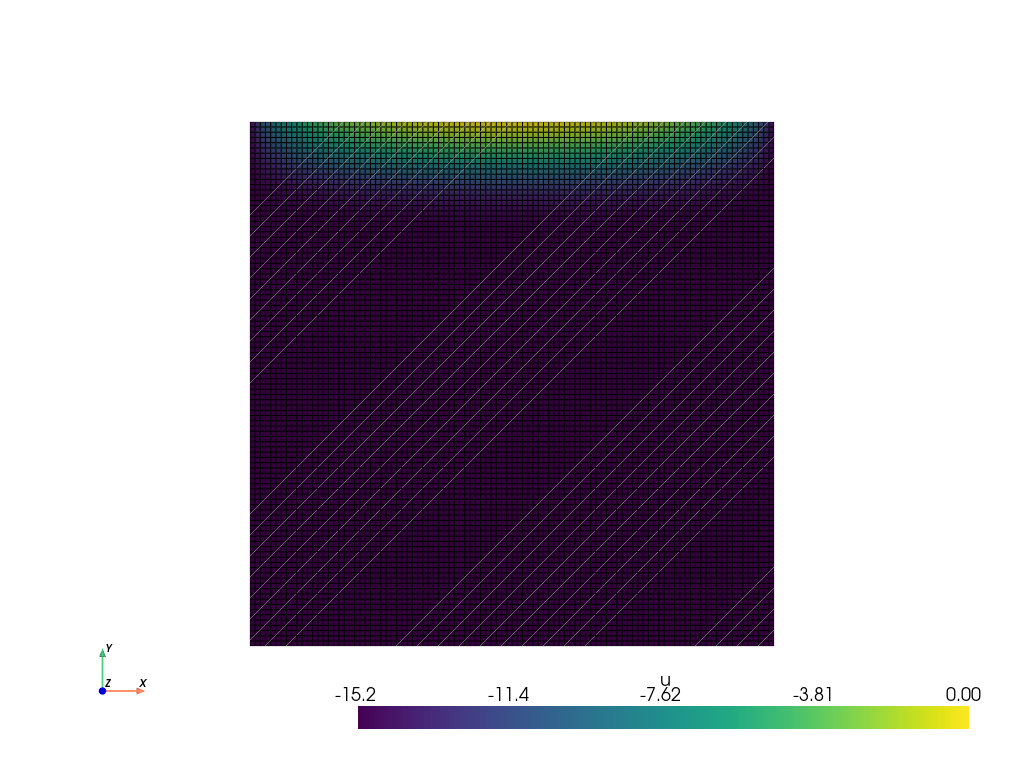

In [27]:
from visualization_fct import *
plotScalarFunction(V,u_n)

Try without "trick"

In [21]:
v = TestFunction(V)
u_n = Function(V)
u_n.x.array[:] = h_r # previous (time step) solution

max_iter = 10 # maximum number of Picard iterations
tol = 1e-6

for n in range(num_steps):
    u_m = Function(V)
    u_m.x.array[:] = u_n.x.array

    u_mp1 = TrialFunction(V)

    F = C(u_m) / delta_t * (u_mp1 - u_n) * v * dx 
    F += inner(Ks * kr(u_m) * grad(x[1] + u_mp1), grad(v)) * dx
    a_fem = lhs(F)
    L_fem = rhs(F)

    eps = 1
    m = 0
    while eps > tol and m < max_iter:
        problem = LinearProblem(
            a_fem, L_fem, bcs=[bc_top_fix, bc_fix],
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix="Picard_",
            )
        u_mp1 = problem.solve()

        diff = u_mp1.x.array - u_m.x.array
        eps = np.linalg.norm(diff, ord=np.inf)
        print(f"Time step {n}, iteration {m}, Error ||u_n^m-u_n^(m+1)|| {eps:.3e}")

        u_m.x.array[:] = u_mp1.x.array
        m += 1
    
    u_n.x.array[:] = u_mp1.x.array

    


        

Time step 0, iteration 0, Error ||u_n^m-u_n^(m+1)|| 1.524e+01
Time step 0, iteration 1, Error ||u_n^m-u_n^(m+1)|| 3.353e+00
Time step 0, iteration 2, Error ||u_n^m-u_n^(m+1)|| 6.987e-01
Time step 0, iteration 3, Error ||u_n^m-u_n^(m+1)|| 1.107e-01
Time step 0, iteration 4, Error ||u_n^m-u_n^(m+1)|| 1.446e-02
Time step 0, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.621e-03
Time step 0, iteration 6, Error ||u_n^m-u_n^(m+1)|| 2.112e-04
Time step 0, iteration 7, Error ||u_n^m-u_n^(m+1)|| 2.197e-05
Time step 0, iteration 8, Error ||u_n^m-u_n^(m+1)|| 2.451e-06
Time step 0, iteration 9, Error ||u_n^m-u_n^(m+1)|| 5.615e-07
Time step 1, iteration 0, Error ||u_n^m-u_n^(m+1)|| 4.684e+00
Time step 1, iteration 1, Error ||u_n^m-u_n^(m+1)|| 8.741e-01
Time step 1, iteration 2, Error ||u_n^m-u_n^(m+1)|| 1.808e-01
Time step 1, iteration 3, Error ||u_n^m-u_n^(m+1)|| 3.346e-02
Time step 1, iteration 4, Error ||u_n^m-u_n^(m+1)|| 5.921e-03
Time step 1, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.069e-03
Time ste

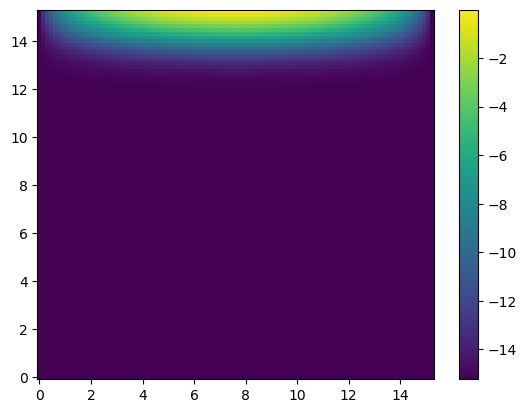

In [28]:
# Grids
x_grid = np.linspace(0, a, 100)
z_grid = np.linspace(0, L, 100)
X, Z = np.meshgrid(x_grid, z_grid)


def eval_try(x, z, u):
    h = np.zeros((len(z), len(x)))
    for i, z_cor in enumerate(z):
        p = np.vstack([x, np.full(len(x), z_cor), np.zeros(len(x))])
        pts, values = evaluate_fct(domain, p, u)
        h[i, :] = np.array(values).flatten()
    return h

heads = eval_try(x_grid, z_grid, [u_n])
plt.pcolormesh(X, Z, heads)
plt.colorbar()